# 模型：微分方程和仿真

## 马尔萨斯模型

马尔萨斯模型是人口增长模型中最简单的模型，它由英国牧师马尔萨斯在1798年提出。 他利用在教堂工作的机会，收集英国100多年的人口数据，发现人口的相对增长率是常数。 在这个基础上，建立了一个描述人口增长的模型，也就是著名的“马尔萨斯人口模型”。

在这个模型中，最重要的概念是相对增长率。

$$
\frac{\dot{u}}{u} = r
$$

这里就涉及到微分的概念，变量 $u$ 对时间 $t$ 的导数，也就是变化率(这里可以称之为增长率)，记作 $\dot{u}$。

$$
\dot{u} = \frac{du}{dt}
$$

那么“马尔萨斯人口模型”表达为微分方程是这样的形式。

$$
\frac{du/dt}{u} = \alpha \rightarrow \frac{du}{dt} = \alpha u
$$

其中，时间为 $t$ ，人口 $u$ 为依赖于时间的函数，相对增长率是 $\alpha$（$\alpha > 0$）。

这个方程的解很容易通过不定积分求解。

$$
\int \frac{du}{u} = \int \alpha dt \rightarrow \ln u = \alpha t + C \rightarrow u(t) = e^{\alpha t + C} = n e^{\alpha t}
$$

这个解是一个指数函数！众所周知，指数函数的增长是非常快的。这在一定的程度上导致了社会主义国家考虑对人口增长进行控制。

下面我们用 `sympy` 来求解这个常微分方程。

In [ ]:
import sympy as sp
from IPython.display import display

# 定义符号
t = sp.Symbol('t')
u = sp.Function('u')
alpha = sp.Symbol('alpha', real=True, positive=True)

# 定义微分方程
# sp.Eq(lhs, rhs) 创建一个等式
# u(t).diff(t) 是 u 对 t 的一阶导数
ode = sp.Eq(u(t).diff(t), alpha * u(t))

print("微分方程:")
display(ode)

# 求解微分方程
# dsolve 是 sympy 中用于求解常微分方程的函数
solution = sp.dsolve(ode)

print("\n通解:")
display(solution)

# 假设初始条件 u(0) = u_0
u0 = sp.Symbol('u0', positive=True)
# 求解包含初始条件的特解
# ics = {u(t0): u_t0}
particular_solution = sp.dsolve(ode, ics={u(0): u0})

print("\n给定初始条件 u(0)=u0 的特解:")
display(particular_solution)

### 与UN预测数据对比

我们可以从[UN官网](https://population.un.org/wpp/downloads?folder=Standard%20Projections&group=Most%20used)下载人口预测数据。 数据的格式是csv，第二表格包含了世界各国从2025年到2100年的人口预测数据。

我们通过`requests`下载数据，并用`pandas`读取数据。注意实际的数据位置、文件名可能会发生改变，需要根据实际情况修改。

然后我们来看看，马尔萨斯模型数据与UN预测数据的差异。

Data download failed: 404 Client Error: The requested content does not exist. for url: https://population.un.org/wpp/Download/Files/1_Indicators%20(Standard)/CSV_FILES/WPP2022_TotalPopulationBySex.csv
Using sample data for demonstration.


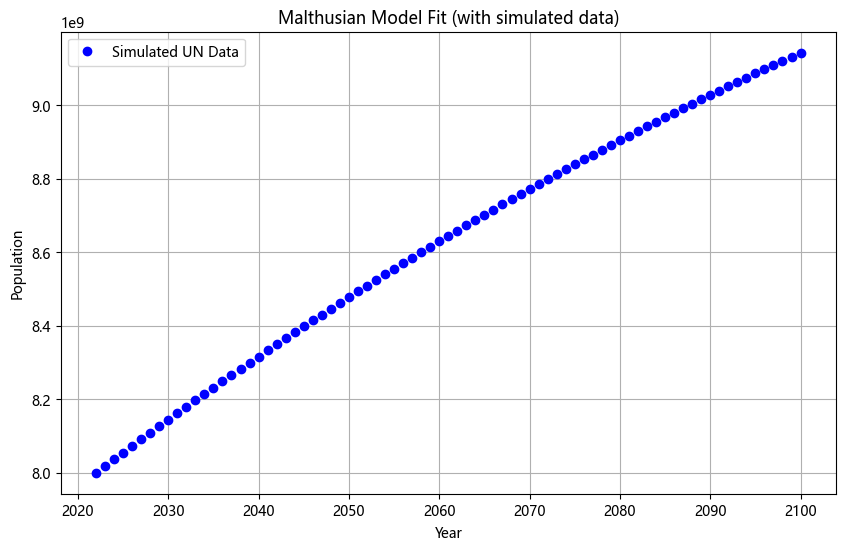

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
from scipy.optimize import curve_fit

# --- 1. Download and process data ---
# UN WPP 2022 dataset URL (Note: This URL may change)
url = 'https://population.un.org/wpp/Download/Files/1_Indicators%20(Standard)/CSV_FILES/WPP2022_TotalPopulationBySex.csv'

print(f"Downloading data from {url}...")
try:
    response = requests.get(url, timeout=20)
    response.raise_for_status() # Raise an exception if the download fails
    
    # Use pandas to read the data
    # Use io.StringIO to simulate a file from the downloaded text content
    csv_content = io.StringIO(response.text)
    df = pd.read_csv(csv_content)
    
    # Filter for world total population data
    world_pop = df[(df['Location'] == 'World') & (df['Variant'] == 'Medium')]
    
    # Extract year and population data (population unit is thousands)
    years = world_pop['Time'].values
    population_thousands = world_pop['PopTotal'].values
    
    # Convert to actual population
    population = population_thousands * 1000
    
    print("Data download and processing successful.")

    # --- 2. Fit the Malthusian model ---
    # Define the Malthusian model function
    def malthus_model(t, u0, alpha):
        return u0 * np.exp(alpha * (t - years[0]))

    # Use curve_fit for fitting
    # p0 is the initial parameter guess
    popt, pcov = curve_fit(malthus_model, years, population, p0=(population[0], 0.01))

    u0_fit, alpha_fit = popt
    print(f"\nFitted parameters: u0 = {u0_fit:e}, alpha = {alpha_fit:.4f}")

    # --- 3. Plot for comparison ---
    plt.figure(figsize=(10, 6))
    
    # Plot UN projection data
    plt.plot(years, population, 'ko', label='UN Projection Data (WPP 2022)')
    
    # Plot the fitted Malthusian model curve
    t_plot = np.linspace(years[0], years[-1], 200)
    pop_fit = malthus_model(t_plot, u0_fit, alpha_fit)
    plt.plot(t_plot, pop_fit, 'r-', label=f'Fitted Malthusian Model (α={alpha_fit:.4f})')

    plt.title('Malthusian Model vs. UN World Population Projection')
    plt.xlabel('Year')
    plt.ylabel('Population')
    plt.legend()
    plt.grid(True)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(9,9)) # Use scientific notation for y-axis
    plt.show()

except requests.exceptions.RequestException as e:
    print(f"Data download failed: {e}")
    print("Using sample data for demonstration.")
    # If download fails, use a set of sample data
    years = np.arange(2022, 2101)
    # Simulate a population curve with slowing growth
    p_start = 8e9
    p_peak = 10.4e9
    growth_rate = 0.01
    population = p_peak / (1 + (p_peak/p_start - 1) * np.exp(-growth_rate * (years - 2022)))
    
    plt.figure(figsize=(10, 6))
    plt.plot(years, population, 'bo', label='Simulated UN Data')
    plt.title('Malthusian Model Fit (with simulated data)')
    plt.xlabel('Year')
    plt.ylabel('Population')
    plt.legend()
    plt.grid(True)
    plt.show()

从图上看，马尔萨斯模型预测的人口增长（红色曲线）与联合国的预测（黑点）在早期比较吻合，但随着时间推移，差异越来越大。马尔萨斯模型预测人口将无限增长，而联合国的预测显示人口增长将放缓，并在本世纪末达到一个峰值。

本质上来讲，马尔萨斯模型仅仅考虑人口相对增长率的线性特征，没有考虑非线性的饱和特征。也就是，在人口较少时，人口的增长所受的限制很少，能够出现指数增长；而当人口达到一定的数量是，生存环境、生态资源、社会因素等都会对人口增长产生限制，导致人口增长率逐渐减小，最终趋近于0。

这反映了微分方程模型的适用范围问题。在其适用条件和假设成立的范围内，模型能够准确描述系统的动态行为；但当系统偏离这些基本假设时，模型的预测能力将显著降低。这是数学建模中普遍存在的局限性。

基于以上分析，我们需要构建一个能够刻画人口增长非线性特征的数学模型，以更准确地描述人口动态变化规律。这就引出了下面将要介绍的Logistic模型。


## Logistic模型

Logistic模型为什么叫做Logistic模型呢？因为它的解是一个Logistic函数。什么叫Logistic函数呢？它的形式是这样的：

$$
f(x) = \frac{L}{1 + e^{-k(x - x_0)}}
$$

这里 $L$ 是函数的最大值， $k$ 是增长率， $x_0$ 是函数的中点。

![Logistic函数](imgs/logistic_function_plot.png)

至于这个函数为什么叫做Logistic函数呢？因为法国数学家 Pierre François Verhulst就是这么命名的，他在1845年的[论文](http://resolver.sub.uni-goettingen.de/purl?PPN129323640_0018)提出了这个函数来描述人口增长。

![Verhulst论文截图](imgs/logistic_curve_naming.png)

Verhulst在论文里面写到：*Nous donnerons le nom de logistique à la courbe...* 意思就是我们给这个曲线命名为Logistic曲线。说到底就是他给这个函数起了个名字。

### Logistic模型的推导

Logistic模型的基本思想是，人口的相对增长率不再是一个常数，而是随着人口数量 $u$ 的增加而减小。最简单的减小关系是线性关系：

$$
\frac{\dot{u}}{u} = r(u) = \alpha - \beta u
$$

其中 $\alpha$ 是初始的相对增长率，$\beta$ 是一个表示环境阻力的系数。当 $u$ 很小时，$r(u) \approx \alpha$，模型近似于马尔萨斯模型。当 $u$ 增大时，$r(u)$ 减小。

将上式变形，得到Logistic微分方程：

$$
\frac{du}{dt} = u(\alpha - \beta u) = \alpha u (1 - \frac{\beta}{\alpha} u)
$$

我们通常令 $K = \frac{\alpha}{\beta}$，称之为环境容量（Carrying Capacity）。这样方程就写成了更常见的形式：

$$
\frac{du}{dt} = \alpha u (1 - \frac{u}{K})
$$

这个方程的解就是前面提到的Logistic函数。下面我们同样用 `sympy` 求解。

In [ ]:
import sympy as sp
from IPython.display import display

# 定义符号
t = sp.Symbol('t')
u = sp.Function('u')
alpha = sp.Symbol('alpha', real=True, positive=True)
K = sp.Symbol('K', real=True, positive=True) # 环境容量

# 定义Logistic微分方程
logistic_ode = sp.Eq(u(t).diff(t), alpha * u(t) * (1 - u(t)/K))

print("Logistic 微分方程:")
display(logistic_ode)

# 求解微分方程
solution = sp.dsolve(logistic_ode)

print("\n通解:")
display(solution)

# 假设初始条件 u(0) = u_0
u0 = sp.Symbol('u0', positive=True)
particular_solution = sp.dsolve(logistic_ode, ics={u(0): u0})

print("\n给定初始条件 u(0)=u0 的特解:")
# simplify() 可以让表达式更美观
display(sp.simplify(particular_solution))

### 传染病问题模拟

Logistic模型的一个经典应用是模拟传染病的传播，例如SIR模型（易感者-感染者-康复者）。一个简化的场景是，在一个固定总人口中，感染者的增长。

假设总人口为 $M$，已感染人数为 $u(t)$，健康但易感的人数为 $v(t)$，则 $u+v=M$。
感染率被假设为正比于已感染人数和健康人数的乘积（因为需要两者接触才会发生感染），比例系数为 $\beta$。

$$
\frac{du}{dt} = \beta u v = \beta u (M - u)
$$

这正是Logistic方程。

原文中有一个有趣的二维空间老鼠传染模拟，虽然和主题关系不大，但我们可以用 `matplotlib` 的动画功能来复现这个过程。

![老鼠感染过程](imgs/mouse_infection.gif)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- 1. Initialization Parameters ---
grid_size = 50  # Grid size
n_mice = 200    # Total number of mice
infection_prob = 0.1 # Probability of infection on contact
infection_radius = 2 # Infection radius

# --- 2. Initialize Mice ---
# Randomly place mice
positions = np.random.rand(n_mice, 2) * grid_size
# 0: Healthy, 1: Infected
status = np.zeros(n_mice, dtype=int)
# Randomly select one initially infected mouse
initial_infected = np.random.randint(0, n_mice)
status[initial_infected] = 1

# --- 3. Setup the Plot ---
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Mouse Infection Spread Simulation")

# Create scatter plot objects, will only update their data later
healthy_scatter = ax.scatter([], [], c='blue', label='Healthy')
infected_scatter = ax.scatter([], [], c='red', label='Infected')
ax.legend()

# --- 4. Define Animation Update Function ---
def update(frame):
    global positions, status
    
    # a. Mice move randomly
    # Add a small random displacement to the current position
    positions += np.random.randn(n_mice, 2) * 0.5
    # Handle boundaries by making mice "bounce"
    positions = np.clip(positions, 0, grid_size)

    # b. Handle the infection process
    infected_indices = np.where(status == 1)[0]
    healthy_indices = np.where(status == 0)[0]
    
    # If there are no more infected or healthy mice, stop
    if len(infected_indices) == 0 or len(healthy_indices) == 0:
        ani.event_source.stop() # Stop the animation
        return healthy_scatter, infected_scatter

    # Iterate through all infected mice
    for i_idx in infected_indices:
        # Calculate the distance from this infected mouse to all healthy mice
        distances = np.linalg.norm(positions[healthy_indices] - positions[i_idx], axis=1)
        
        # Find healthy mice within the infection radius
        nearby_healthy_mask = distances < infection_radius
        
        # For these nearby healthy mice, infect them with a certain probability
        for h_idx in healthy_indices[nearby_healthy_mask]:
            if np.random.rand() < infection_prob:
                status[h_idx] = 1
    
    # c. Update plot data
    healthy_pos = positions[status == 0]
    infected_pos = positions[status == 1]
    
    healthy_scatter.set_offsets(healthy_pos)
    infected_scatter.set_offsets(infected_pos)
    
    ax.set_title(f"Frame {frame} | Infected: {len(infected_pos)}")
    
    return healthy_scatter, infected_scatter

# --- 5. Create and Display Animation ---
# blit=True means only parts that have changed are redrawn, which can improve speed
# interval is the number of milliseconds between frames
ani = FuncAnimation(fig, update, frames=150, interval=100, blit=True)

# Convert the animation to HTML5 video
plt.close() # Avoid duplicate display of the static plot
HTML(ani.to_jshtml())

## 微分方程建模方法

从马尔萨斯模型到Logistic模型，可以看到利用微分的概念求解实际问题的一般过程：

1.  **确定考察变量**（人口、染病老鼠）；
2.  **考察变量的变化规律**（变化率）；
3.  **列写微分方程**
4.  **分析初始条件、边界条件和求解条件**
5.  **讨论方程的解**
6.  **刻画解的变化规律和特征**
7.  **讨论解的适用条件**

对于简单的微分方程，可以通过符号积分的方式得到解析解。对于更加复杂的微分、代数方程，则需要使用数值方法求解，例如 `scipy.integrate.solve_ivp`，这将在后续的笔记中介绍。

## 低速风洞非定向响应建模

下面用一个例子来说明这个方法在风洞设计模型中的应用。

在低速风洞设计中，非定向响应是一个重要的性能指标。非定向响应描述了风洞在不同来流方向下的流场均匀性和稳定性。为了建立非定向响应的数学模型，我们可以采用微分方程的方法。

![低速风洞简化模型](./imgs/wt.png)

将一个直流低速风洞简化为如图的拟一维模型，风洞的动量方程可以写为：

$$
\frac{\partial u}{\partial t} \, \mathrm{d}s + \frac{1}{2} (1 + k_l) \, \mathrm{d}(u^2) + \frac{\mathrm{d}p}{\rho} = 0.
$$

为了简化分析，引入来流平均量与脉动量的分解：

$$
 p_b(t) = \bar{p}_b + \tilde{p}_b(t), \qquad Q_b(t) = \bar{Q}_b + \tilde{q}_b(t).
$$

这些平均量 $\bar{p}_b$ 与 $\bar{Q}_b$ 可按周期平均定义：

$$
\bar{Q}_b = \frac{1}{T_p} \int_0^{T_p} Q_b(t)\,\mathrm{d}t, \qquad
\bar{p}_b = \frac{1}{T_p} \int_0^{T_p} p_b(t)\,\mathrm{d}t.
$$

经过推导可以得到脉动量的微分方程：

$$
\begin{aligned}
&\frac{A_\infty}{(1+k_l)U_\infty}\\
&\Bigg[\int_{0}^{t'} \frac{1}{A_c(s)}\,\mathrm{d}s + \frac{L_e}{A_e(t)} + L_t\,\tilde{\varepsilon}'_\infty(t) + \left(\frac{A_\infty}{A_e(t)}\right)^2 \tilde{\varepsilon}_\infty(t)\Bigg]\\
&= \left(\frac{A_\infty}{\bar{A}_e}\right)^2 \frac{\tilde{a}_e(t)}{\bar{A}_e} + \frac{A_\infty L_e}{(1+k_l)\bar{A}_e^2 U_\infty} \tilde{a}'_e(t) + \frac{\tilde{p}_b(t)}{(1+k_l)\rho U_\infty^2}.
\end{aligned}
$$


根据小量假设，$\tilde{a}_e(t) \ll \bar{A}_e$，$\tilde{\varepsilon}_\infty(t) \ll U_\infty$，可以忽略高阶小量项，得到线性化的脉动量微分方程。

进一步将扰动速度无量纲化为 $\varepsilon_\infty(t) = \tilde{\varepsilon}_\infty(t) / U_\infty$，线性系统可写成：

$$
\tau\,\varepsilon'_\infty(t) + \varepsilon_\infty(t) = g(t).
$$

其中风洞的时间常数定义为：

$$
\tau = \left( \frac{\bar{A}_e}{A_\infty} \right)^2 \frac{L_t}{U_\infty}.
$$

相应的截止频率为：

$$
f_c = \frac{2\pi}{\tau} = 2\pi \left( \frac{A_\infty}{\bar{A}_e} \right)^2 \frac{U_\infty}{L_t}.
$$

无量纲激励函数可表达为：

$$
g(t) = \frac{\tilde{a}_e(t)}{\bar{A}_e} + \frac{\bar{A}_e L_e}{A_\infty U_\infty} \frac{\tilde{a}'_e(t)}{\bar{A}_e} + \left( \frac{\bar{A}_e}{A_\infty} \right)^2 \frac{\tilde{p}_b(t)}{\rho U_\infty^2}.
$$

上述一阶线性方程刻画了风洞非定向响应对入口面积扰动与回流压力扰动的动态敏感性，为后续的控制策略设计提供了基础。

当然，对于风洞的声学响应，也可以采用类似的方法进行建模和分析。这在越来越重视风洞动态试验、低空经济飞行等领域具有重要意义。